In [1]:
import xarray
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms.functional as F
from GeoSSL.geossl.datasets import EuroSATRGB, get_dataset_spec
import torchvision.transforms as T
from torch.utils.data import Dataset

In [2]:
def plot_tile_image(tile_raster):
    red = tile_raster["red"].squeeze()
    green = tile_raster["green"].squeeze()
    blue = tile_raster["blue"].squeeze()

    rgb = np.dstack((red, green, blue))

    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

    plt.figure(figsize=(3,3))
    plt.imshow(rgb)
    plt.axis('off')
    plt.show()

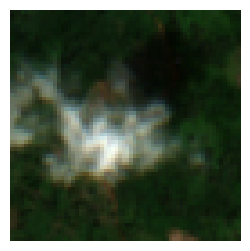

In [3]:
ar = xarray.load_dataset("data/ghana-grid-tiles/tile_5.ncf")
plot_tile_image(ar)

In [4]:
from scripts.gh_tile_dataset import GhanaTileDataset


dataset = GhanaTileDataset("data/ghana-grid-tiles")
print(len(dataset))
print(dataset[0].shape)


ValueError: did not find a match in any of xarray's currently installed IO backends ['netcdf4']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html

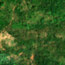

In [ ]:
F.to_pil_image(dataset[389])

In [6]:
dataset_id = "eurosat_rgb"

dataset_spec = get_dataset_spec(dataset_id)
normalize = T.Normalize(mean=dataset_spec.mean, std=dataset_spec.std)

transform = T.Compose(
        [
            T.Resize(dataset_spec.size),
            T.CenterCrop(dataset_spec.crop_size),
            *([T.ToTensor()] if dataset_id == "eurosat_rgb" else []),
            normalize,
        ]
    )

dataset = EuroSATRGB(transform=transform, root="data/eurosat", split="val")

In [7]:
dataset[0]

TypeError: pic should be PIL Image or ndarray. Got <class 'torch.Tensor'>

In [16]:
import os
os.path.basename(dataset.eurosat.imgs[0][0])

'AnnualCrop_1008.tif'